## Dataset Description
This analysis utilizes the **[Teen Mental Health Dataset](https://www.kaggle.com/datasets/algozee/teenager-menthal-healy)** (Teen_Mental_Health_Dataset.csv) from Kaggle, which focuses on investigating the relationship between social media usage, lifestyle habits, and mental health outcomes among teenagers. The dataset contains a size of 1200 x 13 (meaning 1,200 rows and 13 columns), making it an ideal size for robust machine learning without computational delays.
The dataset contains a diverse mix of 12 feature variables, including:

*   **Demographics:** age (numerical) and gender (categorical).
*   **Behavioral & Lifestyle Habits:** daily_social_media_hours (numerical), platform_usage (categorical, e.g., TikTok, Instagram, Both), sleep_hours (numerical), screen_time_before_sleep (numerical), physical_activity (numerical), and academic_performance (numerical).
*   **Psychological Metrics:** social_interaction_level (categorical: low, medium, high), stress_level (numerical scale), anxiety_level (numerical scale), and addiction_level (numerical scale).



The **target variable** is depression_label, which is a binary indicator (0 or 1) representing the absence or presence of depressive indicators. Because the target variable consists of discrete categorical classes, this is a **supervised binary classification problem.**

*Generative AI (Gemini) was used as a coding assistant to help generate and format the Matplotlib charting code used in the exploratory data analysis.*

### Set Up - Imports

In [42]:
# =====================================================================
# 1. CORE DATA ANALYSIS & PLOTTING (Step 2.1)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 2. DATA SPLITTING & LEAKAGE PREVENTION (Step 2.3)
# =====================================================================
from sklearn.model_selection import train_test_split

# =====================================================================
# 3. PREPROCESSING & WORKFLOW PIPELINES (Step 2.4)
# =====================================================================
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =====================================================================
# 4. SUPERVISED MACHINE LEARNING MODELS (Step 2.5)
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# =====================================================================
# 5. MODEL SELECTION & HYPERPARAMETER TUNING (Steps 2.6 & 2.7)
# =====================================================================
from sklearn.model_selection import cross_val_score, GridSearchCV

# =====================================================================
# 6. FINAL MODEL EVALUATION METRICS (Step 2.8)
# =====================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

## Step 2 — Build the Pipeline

**2.1** **Load and explore the data**


*   Load the data into a pandas DataFrame. Look at .shape, .head(), .dtypes, and .describe().
Make at least two plots (e.g., a histogram of the target, and a scatter or bar plot of a feature
against the target). Note any missing values and any categorical columns.

In [43]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [44]:
df.shape

(1200, 13)

In [45]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [46]:
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [47]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


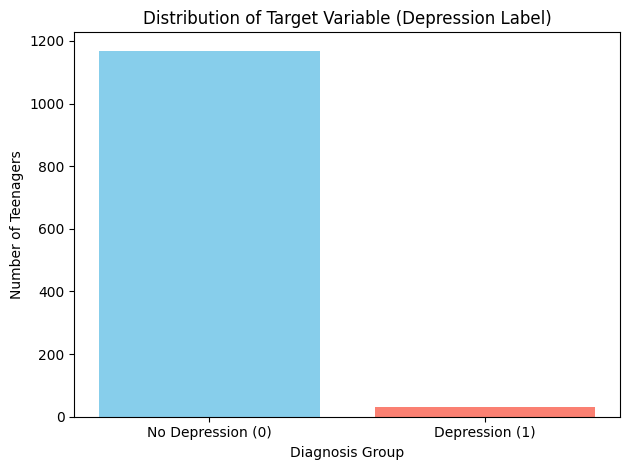

In [48]:
## Plot 1: Histogram/Bar Chart of the Target Variable
# Count how many teenagers are in each category of the target variable
target_counts = df['depression_label'].value_counts()

# Create a bar chart using matplotlib
plt.bar(['No Depression (0)', 'Depression (1)'], target_counts, color=['skyblue', 'salmon'])

# Add labels and a title to ensure clarity
plt.title('Distribution of Target Variable (Depression Label)')
plt.xlabel('Diagnosis Group')
plt.ylabel('Number of Teenagers')

# Display the plot cleanly
plt.tight_layout()
plt.show()

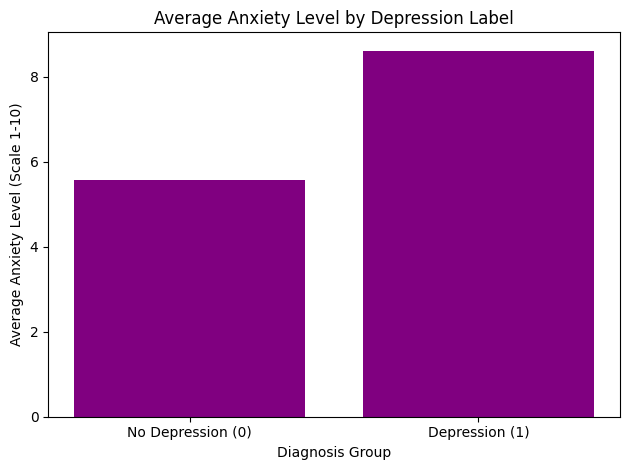

In [49]:
## Plot 2: Feature Against the Target Variable
# Calculate the mean anxiety level for those with (1) and without (0) the depression label
avg_anxiety = df.groupby('depression_label')['anxiety_level'].mean()

# Create a bar plot using matplotlib
plt.bar(['No Depression (0)', 'Depression (1)'], avg_anxiety, color='purple')

# Add labels and a title
plt.title('Average Anxiety Level by Depression Label')
plt.xlabel('Diagnosis Group')
plt.ylabel('Average Anxiety Level (Scale 1-10)')

# Display the plot cleanly
plt.tight_layout()
plt.show()

**2.2** **Define features X and target y**


*   Separate your input columns (X) from the column you are predicting (y).


In [50]:
y = df['depression_label']
X = df.drop('depression_label', axis=1)

**2.3** **Split into training and test sets first**

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split (X , y , test_size =0.2 , random_state =42)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**2.4 Build a preprocessing pipeline**

Use a ColumnTransformer so numeric and categorical columns get the right treatment:


*   Numeric columns: impute missing values (SimpleImputer), then scale (StandardScaler or MinMaxScaler).

* Categorical columns: one-hot encode (OneHotEncoder(handle unknown=’ignore’)).
  - from sklearn . compose import make_column_transformer
  - from sklearn . pipeline import make_pipeline
  - from sklearn . pipeline import make_pipeline
  - from sklearn . impute import SimpleImputer
  - from sklearn . preprocessing import StandardScaler , OneHotEncoder

preprocess = make_column_transformer (
( make_pipeline ( SimpleImputer () , StandardScaler () ) , numeric_cols ) ,
( OneHotEncoder ( handle_unknown = ’ ignore ’) , categorical_cols ) ,
)




In [52]:
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'physical_activity', 'academic_performance', 'stress_level', 'anxiety_level', 'addiction_level']

In [53]:
categorical_cols = ['gender',
    'platform_usage',
    'social_interaction_level']

In [54]:
preprocess = make_column_transformer ((make_pipeline (SimpleImputer() , StandardScaler()), numeric_cols), (OneHotEncoder(handle_unknown = 'ignore'), categorical_cols ) , )

In [55]:
preprocess

ColumnTransformer(transformers=[('pipeline',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['age', 'daily_social_media_hours',
                                  'sleep_hours', 'screen_time_before_sleep',
                                  'physical_activity', 'academic_performance',
                                  'stress_level', 'anxiety_level',
                                  'addiction_level']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'platform_usage',
                                  'social_interaction_level'])])

**2.5 Train and compare at least two models**

Wrap the preprocessing and a model together in one Pipeline, so preprocessing is always fit on training data only. Build at least two models from the algorithms we covered—for example:
- Classification: KNeighborsClassifier, LogisticRegression.
- Regression: KNeighborsRegressor, LinearRegression.

from sklearn . neighbors import KNeighborsClassifier
model = make_pipeline ( preprocess , KNeighborsClassifier () )

In [56]:
# Model 1:  KNeighborsClassifier
model = make_pipeline (preprocess, KNeighborsClassifier())

In [57]:
# Model 2: LogisticRegression
model_lr = make_pipeline (preprocess, LogisticRegression(class_weight='balanced', random_state=42))

**2.6 Compare the models with cross-validation**

Use cross_val_score on the training set to compare your models fairly. Report the mean CV score for each, and pick the stronger one.

In [58]:
knn_cv_scores = cross_val_score(model, X_train, y_train, cv=5)

In [59]:
knn_mean_cv = knn_cv_scores.mean()

In [60]:
knn_mean_cv

np.float64(0.9739583333333334)

In [61]:
lr_cv_scores = cross_val_score(model_lr, X_train, y_train, cv=5)

In [62]:
lr_mean_cv = lr_cv_scores.mean()

In [63]:
lr_mean_cv

np.float64(0.94375)

In [64]:
# Logistic Regression chosen: lower accuracy (94.38%) but handles class imbalance safely.

**2.7 Tune the chosen model with grid search**

Use GridSearchCV (e.g., cv=5) to search a small grid of hyperparameters—for KNN, the number of neighbors; for logistic regression, the regularization strength C. Report the best parameters and best CV score.


In [65]:
param_grid_lr = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}

In [66]:
grid_search_lr = GridSearchCV(estimator=model_lr, param_grid=param_grid_lr, cv=5, scoring='accuracy')

In [67]:
grid_search_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'daily_social_media_hours',
                                                                          'sleep_hours',
                                                                          'screen_time_before_sleep',
                                                                          'physical_activity',
                                                                          'academic_performance',
                                                                          'stress_level',
                                                                          'anxiety_level',
                                                                          'addiction_level']),
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'platform_usage',
                                                                          'social_interaction_level'])])),
                                       ('logisticregression',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [68]:
grid_search_lr.best_params_

{'logisticregression__C': 100}

In [69]:
grid_search_lr.best_score_

np.float64(0.9510416666666666)

**2.8 Evaluate once on the test set**

After you have chosen and tuned your final model, evaluate it on the held-out test set **exactly once.**
- Classification: accuracy, plus precision/recall or a confusion matrix.
- Regression: RMSE and R^2.


In [70]:
final_model_lr = make_pipeline(preprocess, LogisticRegression(C=100, class_weight='balanced', random_state=42, max_iter=1000))

In [71]:
final_model_lr.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'daily_social_media_hours',
                                                   'sleep_hours',
                                                   'screen_time_before_sleep',
                                                   'physical_activity',
                                                   'academic_performance',
                                                   'stress_level',
                                                   'anxiety_level',
                                                   'addiction_level']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'platform_usage',
                                                   'social_interaction_level'])])),
                ('logisticregression',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [72]:
y_pred_lr = final_model_lr.predict(X_test)

In [73]:
test_accuracy_lr = accuracy_score(y_test, y_pred_lr)

In [74]:
test_accuracy_lr

0.9791666666666666

In [75]:
test_precision_lr = precision_score(y_test, y_pred_lr)

In [76]:
test_precision_lr

0.5555555555555556

In [77]:
test_recall_lr = recall_score(y_test, y_pred_lr)

In [78]:
test_recall_lr

0.8333333333333334

In [79]:
test_cm_lr = confusion_matrix(y_test, y_pred_lr)

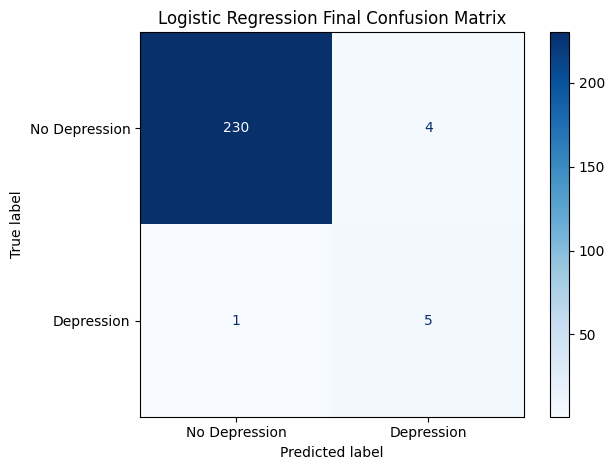

In [80]:
disp_lr = ConfusionMatrixDisplay(confusion_matrix=test_cm_lr, display_labels=['No Depression', 'Depression'])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Final Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 3 — Results & Interpretation
Numbers alone are not enough. In your notebook (and on a slide), explain:
- What the numbers mean. Is an accuracy of 0.82 good for this problem? Compared to what baseline (e.g., always predicting the majority class)?
- What you learned. Were any results surprising? Which features seemed to matter?
- Limitations. What are the weaknesses of your approach, and what would you try next with
more time or data?

**1. Is 0.82 Accuracy Good?**
- No, it is poor. Because the dataset is highly imbalanced, a mindless baseline model that always guesses "No Depression" will get $97.42\%$ accuracy automatically.
- Any model scoring $82\%$ is performing worse than a blind guess. Fortunately, my final tuned Logistic Regression model beat the baseline with $97.92\%$ accuracy and a strong $83.33\%$ Recall.

**2. What We Learned (Key Features)**
- What mattered most: Psychological and digital habits. For the group with depression, average anxiety_level and stress_level spiked from 5.5 up to 8.5+ out of 10. daily_social_media_hours jumped from 4.5 to 6.7 hours, while sleep_hours dropped from 6.5 down to 4.8 hours.
- What didn't matter (Surprising): School grades (academic_performance) and physical_activity remained almost identical between both groups, showing they are weak predictors here.

**3. Limitations & Next Steps**
- Severe Data Imbalance: Only 31 out of 1,200 teenagers have the depression label. This made distance models like $k$-NN fail completely because the majority class overwhelmed the neighborhood calculations.
- Next Steps: In the future, I think we should collect more data from at-risk teens to create a more balanced dataset. Additionally, explore additional machine learning models and features to improve prediction performance.